# 09 - Service aspects associated with dissatisfaction (RQ3)

Two passes. The first tags every substantive review with the ten-aspect bilingual seed lexicon (Appendix D, `src/aspects.py`) and tests each aspect's association with the dissatisfied label: chi-square with Yates's correction, Benjamini-Hochberg adjustment across the ten tests, and the risk ratio as the effect size. Aspects are ranked by risk ratio, not by p-value (Table 15).

The second pass is an independent BERTopic run over the same reviews. Topics that do not map to any lexicon aspect are added as discovered aspects. BERTopic is heavy and optional here: if the package is not installed, the lexicon results stand on their own and the cell says so.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# make src importable when the kernel starts inside notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
from src import config
from src.io import ensure_dirs, save_table, update_metrics, read_metrics
ensure_dirs()

In [2]:
from src.aspects import add_aspect_columns, ASPECTS, ASPECT_DISPLAY
from src.stats import aspect_association

modelling = add_aspect_columns(pd.read_parquet(config.MODELLING_FILE))
aspect_cols = [f"aspect_{a}" for a in ASPECTS]
print(f"substantive reviews: {len(modelling):,}   carrying >= 1 aspect: {(modelling.n_aspects > 0).mean():.1%}")
print((modelling[aspect_cols].mean() * 100).round(1).rename(lambda c: c.replace("aspect_", "")).sort_values(ascending=False))

substantive reviews: 48,930   carrying >= 1 aspect: 56.5%
usability        12.7
update           12.7
performance      12.2
payment          11.4
support           9.6
login             9.5
registration      5.2
verification      4.2
notifications     2.0
language          1.3
dtype: float64


## Table 15 - aspect ranking

In [3]:
t15 = aspect_association(modelling, aspect_cols, "satisfaction_label", config.DISSATISFIED_LABEL)
t15["aspect"] = t15["aspect"].str.replace("aspect_", "")
t15["aspect_display"] = t15["aspect"].map(ASPECT_DISPLAY)
t15.insert(0, "rank", range(1, len(t15) + 1))
save_table(t15, "table15_aspects")
t15.round(4)

,rank,aspect,n_mentions,pct_dissatisfied_mentioning,pct_satisfied_mentioning,risk_ratio,rr_ci_low,rr_ci_high,chi2,p,p_adj,significant,aspect_display
0,1,performance,5949,19.7573,2.6541,7.4441,6.8444,8.0963,3307.2458,0.0000,0.0000,True,Performance / stability
1,2,login,4663,15.2593,2.3643,6.4540,5.8991,7.0611,2328.4185,0.0000,0.0000,True,Login / authentication
2,3,registration,2550,8.0213,1.6973,4.7258,4.2383,5.2694,976.7603,0.0000,0.0000,True,Registration
3,4,verification,2074,6.0316,1.9963,3.0214,2.7222,3.3535,483.6512,0.0000,0.0000,True,Verification
4,5,notifications,956,2.6554,1.0764,2.4670,2.1311,2.8558,156.4162,0.0000,0.0000,True,Notifications
5,6,update,6212,17.2122,7.0469,2.4425,2.3121,2.5803,1125.3500,0.0000,0.0000,True,Updates
6,7,payment,5598,15.1232,6.8353,2.2125,2.0908,2.3413,818.1924,0.0000,0.0000,True,Payment
7,8,language,645,1.2541,1.3983,0.8969,0.7692,1.0457,1.8220,0.1771,0.1771,False,Language
8,9,support,4720,8.2751,11.3615,0.7283,0.6899,0.7690,131.6839,0.0000,0.0000,True,Customer support
9,10,usability,6213,7.0982,19.7010,0.3603,0.3425,0.3790,1729.7830,0.0000,0.0000,True,Usability


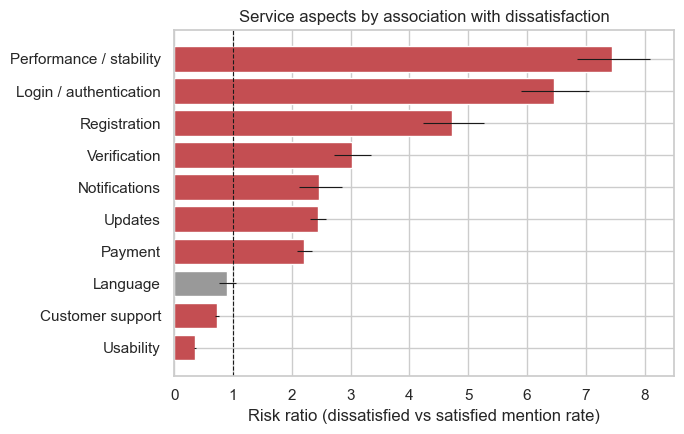

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
d = t15.sort_values("risk_ratio")
ax.barh(d.aspect_display, d.risk_ratio, color=np.where(d.significant, "#C44E52", "#999999"))
ax.errorbar(d.risk_ratio, d.aspect_display, xerr=[d.risk_ratio - d.rr_ci_low, d.rr_ci_high - d.risk_ratio], fmt="none", ecolor="k", lw=0.8)
ax.axvline(1, color="k", lw=0.8, ls="--")
ax.set(xlabel="Risk ratio (dissatisfied vs satisfied mention rate)", title="Service aspects by association with dissatisfaction")
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / "fig_aspect_risk_ratios.png", dpi=220); plt.show()

## Share of dissatisfaction carried by the top aspects (H3)

In [5]:
dis = modelling[modelling.satisfaction_label == config.DISSATISFIED_LABEL]
tagged_dis = dis[dis.n_aspects > 0]
top3 = t15.head(3).aspect.tolist()
share_any_top3 = tagged_dis[[f"aspect_{a}" for a in top3]].any(axis=1).mean()
print(f"dissatisfied reviews with >= 1 aspect: {len(tagged_dis):,} of {len(dis):,} ({len(tagged_dis)/len(dis):.1%})")
print(f"of those, share mentioning at least one of the top-3 aspects by risk ratio ({', '.join(top3)}): {share_any_top3:.1%}")
mention_share = (tagged_dis[aspect_cols].sum() / tagged_dis[aspect_cols].sum().sum() * 100).round(1).rename(lambda c: c.replace("aspect_", "")).sort_values(ascending=False)
print("\nshare of all aspect mentions inside dissatisfied reviews (%):"); print(mention_share)
update_metrics("aspects", {"table15": t15.to_dict(orient="records"), "top3_by_rr": top3,
                           "share_dissatisfied_tagged": float(len(tagged_dis)/len(dis)),
                           "share_top3_among_tagged_dissatisfied": float(share_any_top3),
                           "mention_share_dissatisfied": mention_share.to_dict()})

dissatisfied reviews with >= 1 aspect: 18,060 of 27,190 (66.4%)
of those, share mentioning at least one of the top-3 aspects by risk ratio (performance, login, registration): 54.3%

share of all aspect mentions inside dissatisfied reviews (%):
performance      19.6
update           17.1
login            15.2
payment          15.0
support           8.2
registration      8.0
usability         7.0
verification      6.0
notifications     2.6
language          1.2
dtype: float64


## Second pass - BERTopic (optional, GPU recommended)

In [6]:
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    HAVE_BERTOPIC = True
except ImportError:
    HAVE_BERTOPIC = False
    print("bertopic / sentence-transformers not installed in this environment - "
          "the lexicon pass above is the reported aspect ranking. "
          "Install bertopic and re-run this cell (or run it on the GPU notebook) to add discovered aspects.")

if HAVE_BERTOPIC:
    sample = modelling.sample(min(20000, len(modelling)), random_state=config.RANDOM_SEED)
    emb_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    topic_model = BERTopic(embedding_model=emb_model, language="multilingual", min_topic_size=60,
                           calculate_probabilities=False, verbose=False)
    topics, _ = topic_model.fit_transform(sample.review_text.tolist())
    info = topic_model.get_topic_info()
    info.to_csv(config.TABLES_DIR / "bertopic_topics.csv", index=False)
    display(info.head(25))
    # map each topic to a lexicon aspect by keyword overlap; unmatched topics are candidates for new aspects
    from src.aspects import _LEXICON
    rows = []
    for t in info.Topic:
        if t == -1: continue
        words = [w for w, _ in topic_model.get_topic(t)][:10]
        hit = [a for a, kws in _LEXICON.items() if any(k in " ".join(words) for k in kws)]
        rows.append({"topic": t, "size": int(info.set_index("Topic").loc[t, "Count"]), "top_words": ", ".join(words),
                     "mapped_aspect": "|".join(hit) if hit else "UNMATCHED"})
    mapping = pd.DataFrame(rows)
    save_table(mapping, "bertopic_topic_mapping")
    print("unmatched topics (candidate new aspects):"); display(mapping[mapping.mapped_aspect == "UNMATCHED"])

bertopic / sentence-transformers not installed in this environment - the lexicon pass above is the reported aspect ranking. Install bertopic and re-run this cell (or run it on the GPU notebook) to add discovered aspects.
